# HW02-1：股票收益与组合风险分析

- 姓名：毛博平
- 课程编号：待按教师要求填写（公开版不展示完整学号）
- 作业要求：[第二次作业：金融数据分析](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- 个人 GitHub 仓库地址：https://github.com/ElwinCamnlmen/FinEco-hw
- HW02-1 目录链接：https://github.com/ElwinCamnlmen/FinEco-hw/tree/main/hw02-1
- HW02-2 目录链接：https://github.com/ElwinCamnlmen/FinEco-hw/tree/main/hw02-2
- 数据：AKShare 获取腾讯不复权行情、新浪复权因子、东方财富历史总市值；东方财富公司概况补充行业与上市日期。
- 获取日期：2026-09-27。收益样本：2021-01-04 至 2026-09-16；2020-12-31 为起始估值日。
- AI 使用声明：使用 OpenAI Codex 协助取数、代码、图表、分析文字与程序核验；本人阅读和核验尚待完成，不将自动核验冒充本人核验。

本报告选择金融、食品饮料、家电、公用事业、医药生物五个行业的十只 A 股，先检查行情、复权和历史市值，再比较个股收益分布与共同波动，最后比较每日等权和上一交易日总市值加权组合。本报告使用冻结数据快照、统一交易日历和相同评价区间，关注本样本内的风险收益差异。样本为事后选定，不是历史可实施选股策略。

## 1. 环境与数据来源

### 分析说明
将数据获取和分析分开：下载脚本保留来源、参数、时间和校验值；本 Notebook 只读取本地快照。主分析采用腾讯不复权收盘价乘新浪后复权因子得到的调整价，不复权收盘价用于价格展示，成交额采用人民币元。腾讯前复权价仅用于口径敏感性比较。总市值来自东方财富 `stock_value_em` 的“总市值”（元），不使用“流通市值”。

- AKShare 版本与运行依赖显示在下方；接口不可用时不悄悄替换数据。
- 新浪后复权因子按生效日期向后沿用，构造 $P^{adj}=P^{raw}F^{hfq}$。采用同一来源的前复权因子构造 $P^{raw}/F^{qfq}$ 交叉验证收益率一致性。因子沿用表示公司行为调整系数未变，不是填补缺失价格。
- 复权价不是实际成交价，也不用于市值计算。现金分红、送转配由来源因子反映，不额外重复加分红；该口径不模拟税费和具体再投资成交时点。所有快照固定，防止源数据更新改变结果。
- 数据库更新至样本截止日之后的记录会被显式截断；行业取下载日的东方财富 EM2016 一级分类，仅用于本次固定篮子描述。

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
from IPython.display import display

# 在本题目录或整个仓库根目录打开均可；不写死机器路径。
candidates=[Path.cwd(),Path.cwd()/'hw02-1',Path.cwd()/'FinEco-hw/hw02-1',Path.cwd().parent/'FinEco-hw/hw02-1']
BASE=next((p for p in candidates if (p/'data/manifest.json').is_file()),candidates[0])
assert (BASE / 'data' / 'manifest.json').is_file(), '请从 hw02-1 或仓库根目录运行'
RAW, RESULT = BASE / 'data' / 'raw', BASE / 'results'
RESULT.mkdir(exist_ok=True)
sys.path.insert(0, str(BASE / 'code'))
from download import STOCKS

# 优先选择安装在当前系统中的中文字体，缺失时明确报错。
font_names={f.name for f in font_manager.fontManager.ttflist}
chosen=next((f for f in ['Arial Unicode MS','PingFang SC','Microsoft YaHei','SimHei','Noto Sans CJK SC','WenQuanYi Zen Hei'] if f in font_names),None)
assert chosen, '缺少中文字体，请按 README 安装中文字体后重跑'
plt.rcParams.update({'font.family':chosen,'axes.unicode_minus':False,'figure.dpi':110,
                     'axes.spines.top':False,'axes.spines.right':False,'axes.titleweight':'bold',
                     'axes.grid':True,'grid.alpha':0.2,'savefig.bbox':'tight'})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.6f}')
manifest=json.loads((BASE/'data/manifest.json').read_text(encoding='utf-8'))
print('Python',platform.python_version(),'pandas',pd.__version__,'numpy',np.__version__,'matplotlib',matplotlib.__version__)
print('下载使用 AKShare',manifest['akshare'],'；中文字体：',chosen)

# 每个输入文件必须能在来源清单中找到，且当前内容与下载时一致。
entry_by_file={e['file']:e for e in manifest['entries'] if e.get('status')=='ok' and 'file' in e}
checked=[]
for code_ in STOCKS:
    for kind in ['raw','qfq','value','profile','hfq_factor','qfq_factor']:
        name=f'{code_}_{kind}.csv'
        assert name in entry_by_file, f'来源清单缺少 {name}'
        assert hashlib.sha256((RAW/name).read_bytes()).hexdigest()==entry_by_file[name]['sha256'],f'{name} 已变化'
        checked.append(name)
calendar_file=RAW/'calendar_sh000001.csv'
assert hashlib.sha256(calendar_file.read_bytes()).hexdigest()==entry_by_file[calendar_file.name]['sha256']
print(f'已核验 {len(checked)+1} 个输入文件的 SHA256。')

Python 3.12.14 pandas 3.0.6 numpy 2.5.3 matplotlib 3.11.2
下载使用 AKShare 1.18.97 ；中文字体： Arial Unicode MS
已核验 61 个输入文件的 SHA256。


### 来源核验解读
本题分析不依赖教师重跑时的实时接口状态。下载过程中，东方财富行情接口无法连接，因而采用 AKShare 的腾讯行情接口；历史市值仍由东方财富估值接口提供。两者的不复权收盘价在后续逐日交叉比较，而不是因代码相同就假定完全一致。来源清单包含实际使用版本、参数、时间及数据指纹。

## 2. 选股与样本范围

### 分析说明
每个一级行业选两只股票，兼顾不同商业模式及同行业比较，均须在 2021 年前上市。先按上市时间、行业分布和完整行情覆盖确定篮子，再计算比较结果，没有按最终涨幅选股。

- 分类标准：东方财富公司概况字段 `EM2016`，取第一个层级，分类日期为 2026-09-27。
- 最初候选宁波银行与长江电力分别缺少 6 和 11 个交易日。宁波银行缺口与 2021 年配股停牌日程相符；原始文件保留作覆盖审计。为满足同一连续评价期的要求，选择行情完整的兴业银行、国投电力替代。
- 这种覆盖筛选仍会偏向交易连续的存续股票，不能据此代表全部 A 股。替代依据不是收益表现。

In [2]:
selection=[]
for code_,(name,reason) in STOCKS.items():
    row=pd.read_csv(RAW/f'{code_}_profile.csv',dtype={'SECURITY_CODE':str}).iloc[0]
    assert row['SECURITY_CODE'].zfill(6)==code_
    selection.append({'代码':code_,'简称':name,'行业':row['EM2016'].split('-')[0],
        '完整分类':row['EM2016'],'上市日期':str(row['LISTING_DATE'])[:10],
        '分类日期':'2026-09-27','选股理由':reason})
selection=pd.DataFrame(selection).set_index('代码')
assert len(selection)==10 and selection['行业'].nunique()>=5
assert pd.to_datetime(selection['上市日期']).lt('2021-01-01').all()
display(selection)
selection.to_csv(RESULT/'selection.csv',encoding='utf-8-sig')
names=selection['简称'].to_dict()
colors={c:plt.get_cmap('tab10')(i) for i,c in enumerate(STOCKS)}
summary={'selection':selection.reset_index().to_dict('records')}

,简称,行业,完整分类,上市日期,分类日期,选股理由
代码,,,,,,
601166,兴业银行,金融,金融-银行-股份制与城商行,2007-02-05,2026-09-27,全国性银行，与区域银行比较，优先使用行情覆盖完整的样本
601009,南京银行,金融,金融-银行-股份制与城商行,2007-07-19,2026-09-27,区域银行，与兴业银行构成同行业比较
600519,贵州茅台,食品饮料,食品饮料-饮料-白酒,2001-08-27,2026-09-27,白酒品牌企业，代表消费品商业模式
000858,五粮液,食品饮料,食品饮料-饮料-白酒,1998-04-27,2026-09-27,白酒品牌企业，与贵州茅台构成同行业比较
000651,格力电器,家电,家电-白色家电-白色家电,1996-11-18,2026-09-27,耐用消费品制造企业，关注制造业风险
002032,苏泊尔,家电,家电-小家电-小家电,2004-08-17,2026-09-27,厨房电器企业，比较家电行业内部差异
600886,国投电力,公用事业,公用事业-电力-水电,1996-01-18,2026-09-27,电力运营企业，与华能水电比较，优先使用行情覆盖完整的样本
600025,华能水电,公用事业,公用事业-电力-水电,2017-12-15,2026-09-27,水电运营企业，与国投电力构成同行业比较
600276,恒瑞医药,医药生物,医药生物-化学制药-化学制剂,2000-10-18,2026-09-27,药品研发生产企业，代表医药业务


### 结果解读
最终篮子为兴业银行、南京银行、贵州茅台、五粮液、格力电器、苏泊尔、国投电力、华能水电、恒瑞医药和片仔癀，五个一级行业各两只。最晚上市的是华能水电（2017-12-15），因此不存在在研究期内才上市却人为补造早期价格的问题。银行、白酒和水电提供较直接的行业内比较，家电和医药的两家企业则具有不同细分业务，预期相关性未必同样高。

- 10 只股票、5 个统一标准的一级行业，满足覆盖要求。
- 分类是 2026-09-27 的固定描述，不声称还原历史行业选股。
- 宁波银行与长江电力保留在候选覆盖记录中，不进入最终组合。

## 3. 日期、主键、缺失及单位审计

### 分析说明
以上证指数实际行情日期作为共同交易日历，从 2020-12-31 开始。每只股票先检查日期键唯一、日期排序和原始有效区间，再对齐日历；对齐后的缺失保持缺失，不填零、不先删除缺口再计算收益。

- 如果最终篮子任何一只股票缺少价格或总市值，程序停止，要求回查来源。
- 历史总市值只在交易日对齐后移位一期。市值为正，且用不复权收盘价乘当日总股本核查数量级；这一乘法仅用于核验，不替代来源市值。
- 成交额为本题的交易活跃度字段；AKShare 1.18.97 的腾讯接口在部分 `sz000` 股票上存在成交量换算分支差异，本报告保留原始 volume，不将它用于指标或市值计算，以避免混用股/手。

In [3]:
calendar_raw=pd.read_csv(calendar_file,parse_dates=['date'])
assert not calendar_raw['date'].duplicated().any()
calendar=pd.DatetimeIndex(calendar_raw['date']).sort_values()
assert calendar[0]==pd.Timestamp('2020-12-31') and calendar[-1]==pd.Timestamp('2026-09-16')
close=pd.DataFrame(index=calendar); adj=close.copy(); mv=close.copy(); amount=close.copy()
tx_adj=close.copy(); factor=close.copy(); sine_qfq_adj=close.copy(); factor_checks=[]
audit=[]; unit_rows=[]; originals={}
for code_ in STOCKS:
    raw=pd.read_csv(RAW/f'{code_}_raw.csv',parse_dates=['date'])
    qfq=pd.read_csv(RAW/f'{code_}_qfq.csv',parse_dates=['date'])
    val=pd.read_csv(RAW/f'{code_}_value.csv',parse_dates=['数据日期'])
    for frame,key in [(raw,'date'),(qfq,'date'),(val,'数据日期')]:
        assert frame[key].notna().all()
        assert not frame[key].duplicated().any(),f'{code_} 主键重复'
        assert frame[key].is_monotonic_increasing,f'{code_} 日期未排序'
    raw=raw.set_index('date'); qfq=qfq.set_index('date'); val=val.set_index('数据日期')
    originals[code_]=raw
    close[code_]=raw['close'].reindex(calendar)
    tx_adj[code_]=qfq['close'].reindex(calendar)
    aligned_factors={}
    for kind in ['hfq','qfq']:
        f=pd.read_csv(RAW/f'{code_}_{kind}_factor.csv',parse_dates=['date'])
        assert not f['date'].duplicated().any() and f['date'].notna().all()
        f=f.set_index('date')[f'{kind}_factor'].astype(float).sort_index()
        assert f.gt(0).all()
        aligned_factors[kind]=f.reindex(f.index.union(calendar)).sort_index().ffill().reindex(calendar)
        assert aligned_factors[kind].notna().all()
    factor[code_]=aligned_factors['hfq']
    adj[code_]=close[code_]*factor[code_]
    sine_qfq_adj[code_]=close[code_]/aligned_factors['qfq']
    consistency=(adj[code_].pct_change(fill_method=None)-sine_qfq_adj[code_].pct_change(fill_method=None)).abs().max()
    assert consistency<1e-8, '新浪前后复权因子对应收益率不一致'
    changed=factor[code_].pct_change(fill_method=None).abs()>1e-10
    factor_checks.append({'股票':names[code_],'样本内因子变动天数':int(changed.sum()),'两种新浪因子收益最大差':consistency})
    mv[code_]=val['总市值'].reindex(calendar)
    amount[code_]=raw['amount'].reindex(calendar)
    cross=(close[code_]-val['当日收盘价'].reindex(calendar)).abs()
    implied=close[code_]*val['总股本'].reindex(calendar)
    discrepancy=(mv[code_]/implied-1).abs()
    audit.append({'代码':code_,'简称':names[code_],'起始日':raw.index.min().strftime('%Y-%m-%d'),
        '截止日':raw.index.max().strftime('%Y-%m-%d'),'价格行数':len(raw),'重复日期':int(raw.index.duplicated().sum()),
        '未复权价缺失':int(close[code_].isna().sum()),'复权价缺失':int(adj[code_].isna().sum()),
        '市值缺失':int(mv[code_].isna().sum()),'成交额缺失':int(amount[code_].isna().sum())})
    unit_rows.append({'简称':names[code_],'跨来源价格最大差/元':cross.max(),
        '市值与价乘股数最大相对差':discrepancy.max(),
        '成交额最小值/元':amount[code_].min(),'成交额最大值/亿元':amount[code_].max()/1e8,
        '非正成交额天数':int(amount[code_].le(0).sum())})
audit=pd.DataFrame(audit); unit_audit=pd.DataFrame(unit_rows)
display(audit); display(unit_audit)
assert close.notna().all().all() and adj.notna().all().all() and mv.notna().all().all()
assert (close>0).all().all() and (adj>0).all().all() and (mv>0).all().all()
assert amount.notna().all().all() and (amount>=0).all().all()
assert unit_audit['跨来源价格最大差/元'].max()<=0.011, '跨来源价格不一致，需核验'
assert unit_audit['市值与价乘股数最大相对差'].max()<0.01, '市值口径或单位需核验'
audit.to_csv(RESULT/'data_audit.csv',index=False,encoding='utf-8-sig')
unit_audit.to_csv(RESULT/'unit_audit.csv',index=False,encoding='utf-8-sig')
display(pd.DataFrame(factor_checks))
pd.DataFrame(factor_checks).to_csv(RESULT/'factor_audit.csv',index=False,encoding='utf-8-sig')
summary['factor_checks']=factor_checks
summary['audit']={'n_calendar':len(calendar),'price_diff':float(unit_audit['跨来源价格最大差/元'].max()),
                 'mv_error':float(unit_audit['市值与价乘股数最大相对差'].max()),'amount_zero':int(unit_audit['非正成交额天数'].sum())}

,代码,简称,起始日,截止日,价格行数,重复日期,未复权价缺失,复权价缺失,市值缺失,成交额缺失
0,601166,兴业银行,2020-12-31,2026-09-16,1385,0,0,0,0,0
1,601009,南京银行,2020-12-31,2026-09-16,1385,0,0,0,0,0
2,600519,贵州茅台,2020-12-31,2026-09-16,1385,0,0,0,0,0
3,000858,五粮液,2020-12-31,2026-09-16,1385,0,0,0,0,0
4,000651,格力电器,2020-12-31,2026-09-16,1385,0,0,0,0,0
5,002032,苏泊尔,2020-12-31,2026-09-16,1385,0,0,0,0,0
6,600886,国投电力,2020-12-31,2026-09-16,1385,0,0,0,0,0
7,600025,华能水电,2020-12-31,2026-09-16,1385,0,0,0,0,0
8,600276,恒瑞医药,2020-12-31,2026-09-16,1385,0,0,0,0,0
9,600436,片仔癀,2020-12-31,2026-09-16,1385,0,0,0,0,0


,简称,跨来源价格最大差/元,市值与价乘股数最大相对差,成交额最小值/元,成交额最大值/亿元,非正成交额天数
0,兴业银行,0.000000,0.000000,"297,789,000.000000",82.859661,0
1,南京银行,0.000000,0.000000,"49,271,900.000000",37.343653,0
2,贵州茅台,0.000000,0.000000,"1,445,537,300.000000",351.140750,0
3,五粮液,0.000000,0.000000,"674,597,100.000000",222.182310,0
4,格力电器,0.000000,0.000000,"367,412,200.000000",108.603368,0
5,苏泊尔,0.000000,0.000000,"23,733,500.000000",6.965089,0
6,国投电力,0.000000,0.000000,"57,861,200.000000",26.778430,0
7,华能水电,0.000000,0.000000,"51,710,200.000000",17.145489,0
8,恒瑞医药,0.000000,0.000000,"548,157,600.000000",138.323464,0
9,片仔癀,0.000000,0.000000,"137,367,100.000000",62.651810,0


,股票,样本内因子变动天数,两种新浪因子收益最大差
0,兴业银行,7,0.000000
1,南京银行,8,0.000000
2,贵州茅台,10,0.000000
3,五粮液,8,0.000000
4,格力电器,10,0.000000
5,苏泊尔,7,0.000000
6,国投电力,6,0.000000
7,华能水电,6,0.000000
8,恒瑞医药,6,0.000000
9,片仔癀,8,0.000000


### 结果解读
最终每只股票包含 1385 个共同交易日价格，产生 1384 个日收益，评价期为 2021-01-04—2026-09-16。价格、复权因子、总市值和成交额均覆盖所需日历，最终样本无需删除日期、填补收益或暂停再平衡。腾讯与东方财富不复权收盘价逐日最大差为 0.00 元，来源总市值与原始价乘总股本的相对误差不超过 2.22e-16，属于浮点误差量级。

新浪前后复权因子生成的收益率通过一致性校验。在因子未变的日期，调整后收益与原始价收益的最大差为 2.22e-16，避免把复权价的平移误当成市场涨跌。

- 主键无重复，最终样本无交易日缺口；这些结论仅适用于本次快照。
- 两个来源的原始价逐日一致，历史市值单位和股本口径一致。
- 未填零、未缩尾，原始输入与检查结果均保留。

## 4. 不复权价格与日收益率

### 分析说明
不复权价格分面展示，避免高价股压缩其他股票的价格变化。日简单收益率严格使用相邻交易日复权收盘价：

$$r_{i,t}=P^{adj}_{i,t}/P^{adj}_{i,t-1}-1.$$

收益的第一天为 2021-01-04，其分母为 2020-12-31。异常检查报告每只股票的最大绝对收益日及全部绝对收益超过 10.5% 的记录，结合当日原始价格变化和复权调整比率判断；阈值只是定位线索，不直接作为删除标准。极端行情可能是真实信息，不因为数值大就缩尾。

findfont: Failed to find font weight bold for Arial Unicode MS, now using 400.


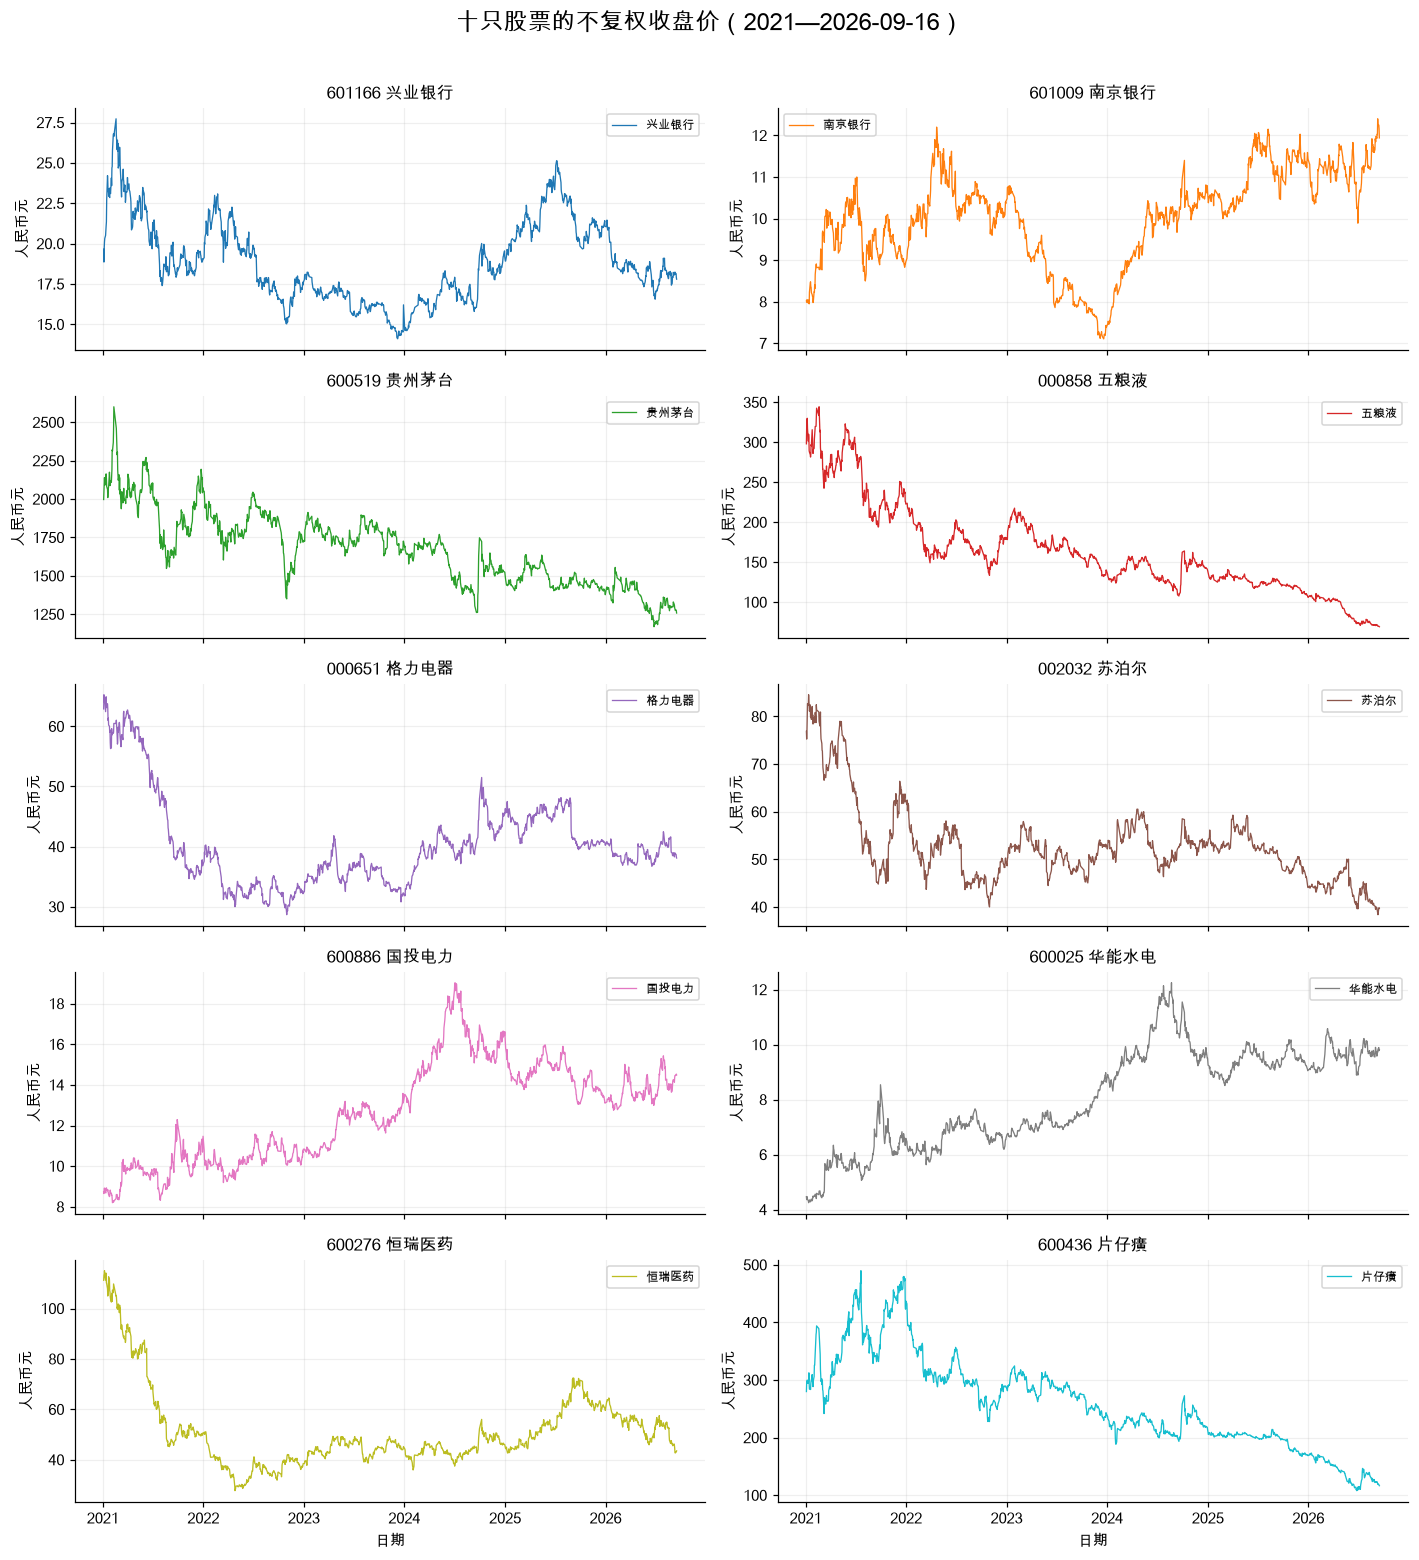

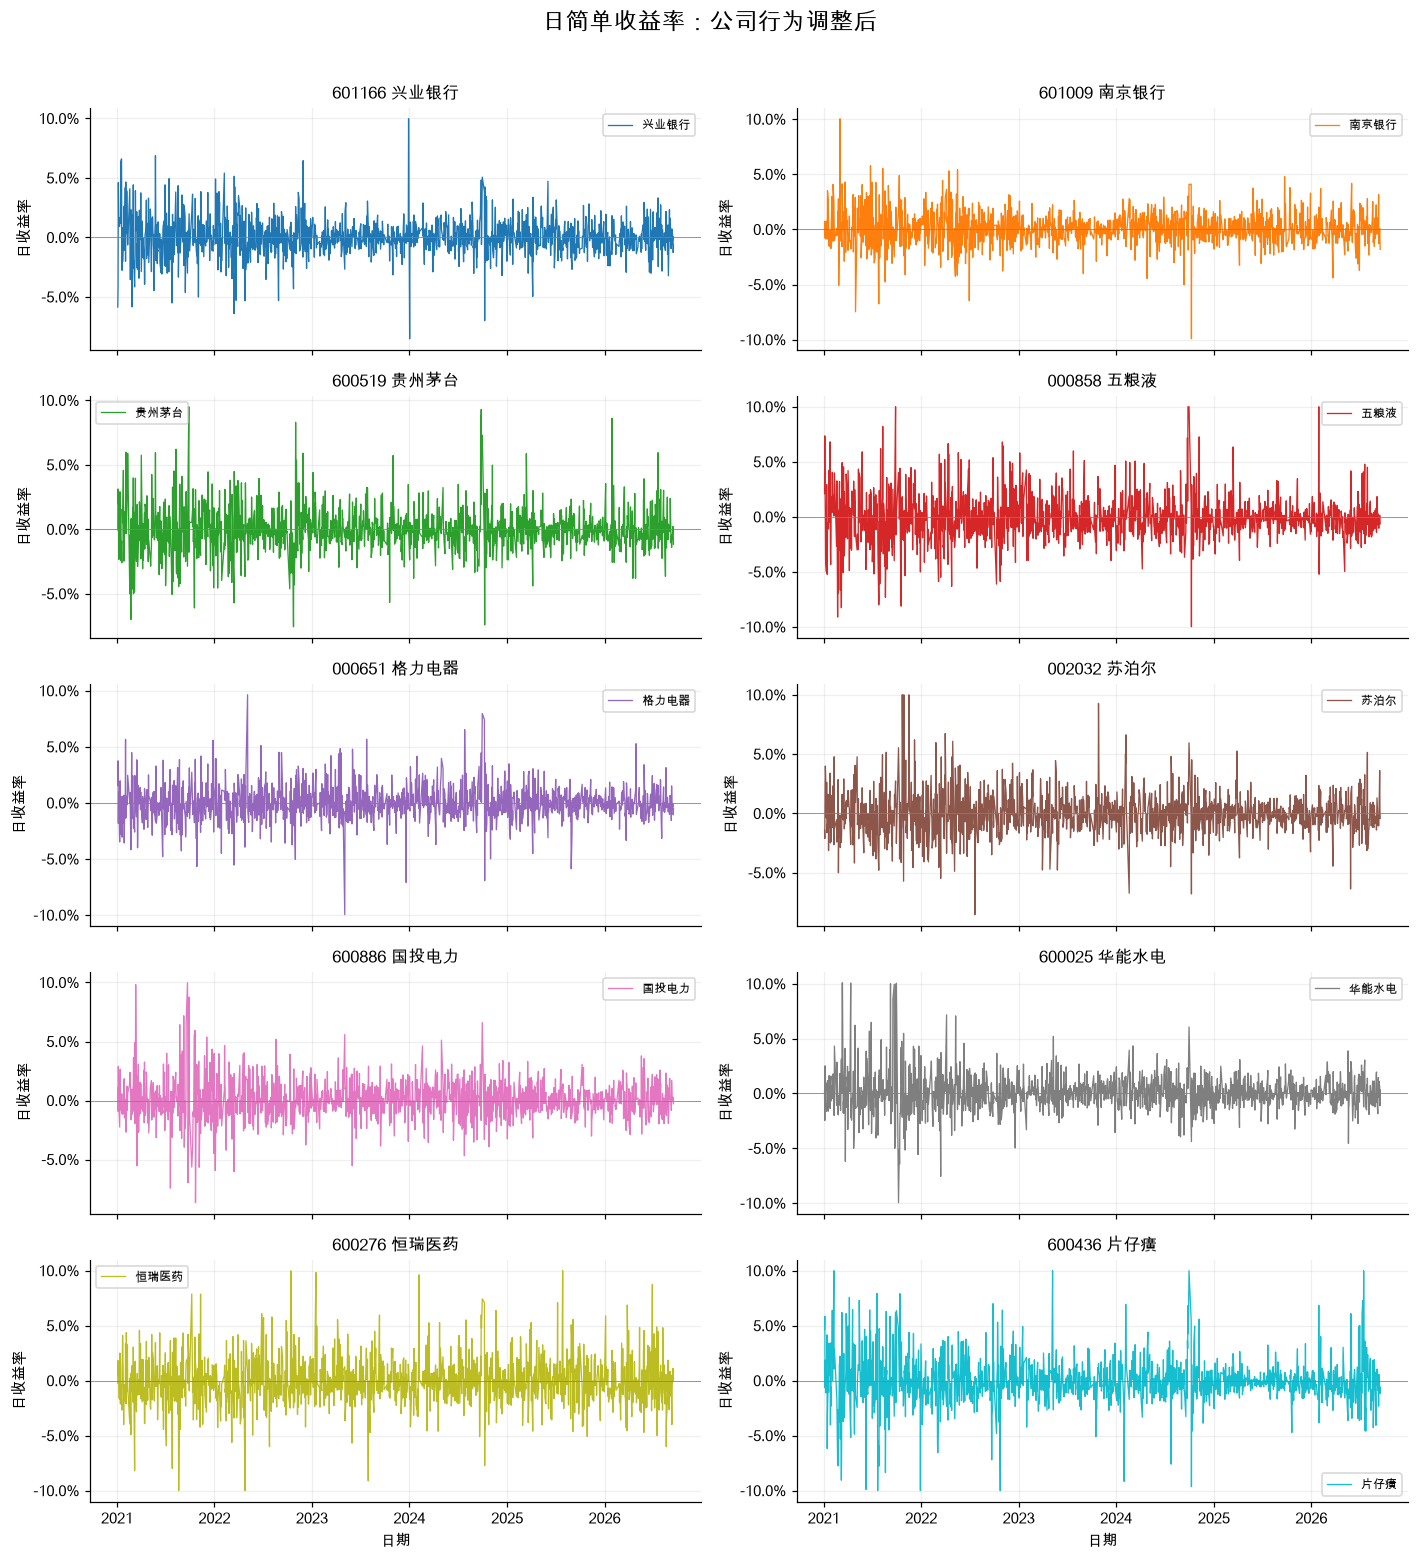

,日期,股票,代码,复权日收益率,不复权价格变动,调整比率变动,超过10.5%
9,2022-10-24,片仔癀,600436,-10.00%,-10.00%,0.0000%,False
8,2022-04-25,恒瑞医药,600276,-10.00%,-10.00%,0.0000%,False
4,2023-05-04,格力电器,000651,-9.96%,-9.96%,0.0000%,False
2,2021-09-27,贵州茅台,600519,9.50%,9.50%,0.0000%,False
0,2023-12-29,兴业银行,601166,9.97%,9.97%,0.0000%,False
6,2021-09-22,国投电力,600886,9.98%,9.98%,0.0000%,False
3,2024-09-26,五粮液,000858,10.00%,10.00%,0.0000%,False
5,2021-10-22,苏泊尔,002032,10.01%,10.01%,0.0000%,False
1,2021-03-03,南京银行,601009,10.03%,10.03%,0.0000%,False
7,2021-03-12,华能水电,600025,10.10%,10.10%,0.0000%,False


In [4]:
def panel_lines(frame,title,ylabel,filename,percent=False,zero=False):
    fig,axes=plt.subplots(5,2,figsize=(13,14),sharex=True)
    for ax,c in zip(axes.flat,STOCKS):
        ax.plot(frame.index,frame[c],color=colors[c],lw=0.85,label=names[c])
        ax.set_title(f'{c} {names[c]}',fontsize=11); ax.set_ylabel(ylabel)
        ax.legend(loc='best',fontsize=8)
        if percent: ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
        if zero: ax.axhline(0,color='grey',lw=0.5)
    for ax in axes[-1]: ax.set_xlabel('日期')
    fig.suptitle(title,fontsize=16,y=1.01); fig.tight_layout()
    fig.savefig(RESULT/filename,dpi=150); plt.show()

panel_lines(close.loc['2021-01-01':],'十只股票的不复权收盘价（2021—2026-09-16）','人民币元','01_prices.png')
returns=adj.pct_change(fill_method=None).loc['2021-01-01':'2026-09-16']
assert len(returns)==len(calendar)-1 and returns.notna().all().all()
assert (returns>-1).all().all()
raw_returns=close.pct_change(fill_method=None).reindex(returns.index)
adjustment_change=(adj/close).pct_change(fill_method=None).reindex(returns.index)
panel_lines(returns,'日简单收益率：公司行为调整后','日收益率','02_daily_returns.png',percent=True,zero=True)

extreme_rows=[]
for c in STOCKS:
    flagged=returns.index[returns[c].abs()>0.105].union(pd.DatetimeIndex([returns[c].abs().idxmax()]))
    for date in flagged:
        extreme_rows.append({'日期':date.strftime('%Y-%m-%d'),'股票':names[c],'代码':c,
          '复权日收益率':returns.at[date,c],'不复权价格变动':raw_returns.at[date,c],
          '调整比率变动':adjustment_change.at[date,c],'超过10.5%':bool(abs(returns.at[date,c])>0.105)})
extremes=pd.DataFrame(extreme_rows).sort_values('复权日收益率')
display(extremes.style.format({'复权日收益率':'{:.2%}','不复权价格变动':'{:.2%}','调整比率变动':'{:.4%}'}))
extremes.to_csv(RESULT/'extreme_returns.csv',index=False,encoding='utf-8-sig')
summary['extremes']=extremes.to_dict('records')
summary['return_period']={'start':returns.index.min().strftime('%Y-%m-%d'),'end':returns.index.max().strftime('%Y-%m-%d'),'T':len(returns)}

### 结果解读
主口径下没有日收益绝对值超过 10.5% 的记录；这不意味着不存在尾部风险。片仔癀在 2022-10-24 的日收益为 -10.00%，恒瑞医药在 2022-04-25 为 -10.00%，均接近当日未复权价格跌幅。华能水电的最大单日收益为 10.10%；略超过整数 10% 可能与报价最小变动单位及价格四舍五入有关，单凭整数阈值不足以认定错误。

初始腾讯前复权口径有 29 个绝对收益超过 10.5% 的股票日。以格力电器 2022-05-05 为例，腾讯前复权收益为 15.90%，而原始价格变化和新浪因子口径均为 9.64%，当日新浪因子未变。因此报告更换统一复权算法，保留日期和原始文件，不把这些记录直接删掉。复权处理是本题发现并解决的主要数据问题；具体新闻与收益之间的因果关系未作验证。

- 极端收益与原始价、因子变化一同审计，不机械缩尾。
- 分面价格用于看各股走势，不能用每股价格高低判断公司规模。
- 口径敏感性结果见第 9 节。

## 5. 累计表现与滚动波动率

### 分析说明
累计净值在 2020-12-31 设为 1，随后逐日连乘 $1+r$，不把收益简单相加。滚动波动率为 20 个连续交易日的样本标准差乘 $\sqrt{252}$，不足 20 个收益观测不显示。

- 各股累计曲线使用相同起点，便于比较财富变化。
- 波动率衡量收益离散程度，不能当成下跌概率或未来保证。

findfont: Failed to find font weight bold for Arial Unicode MS, now using 400.


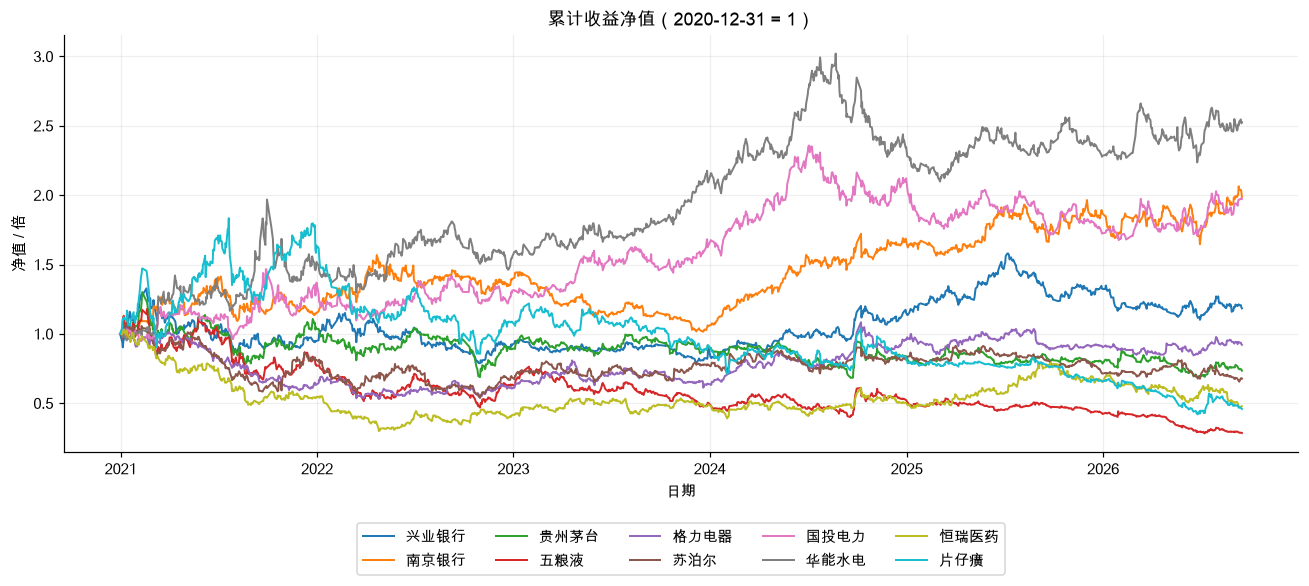

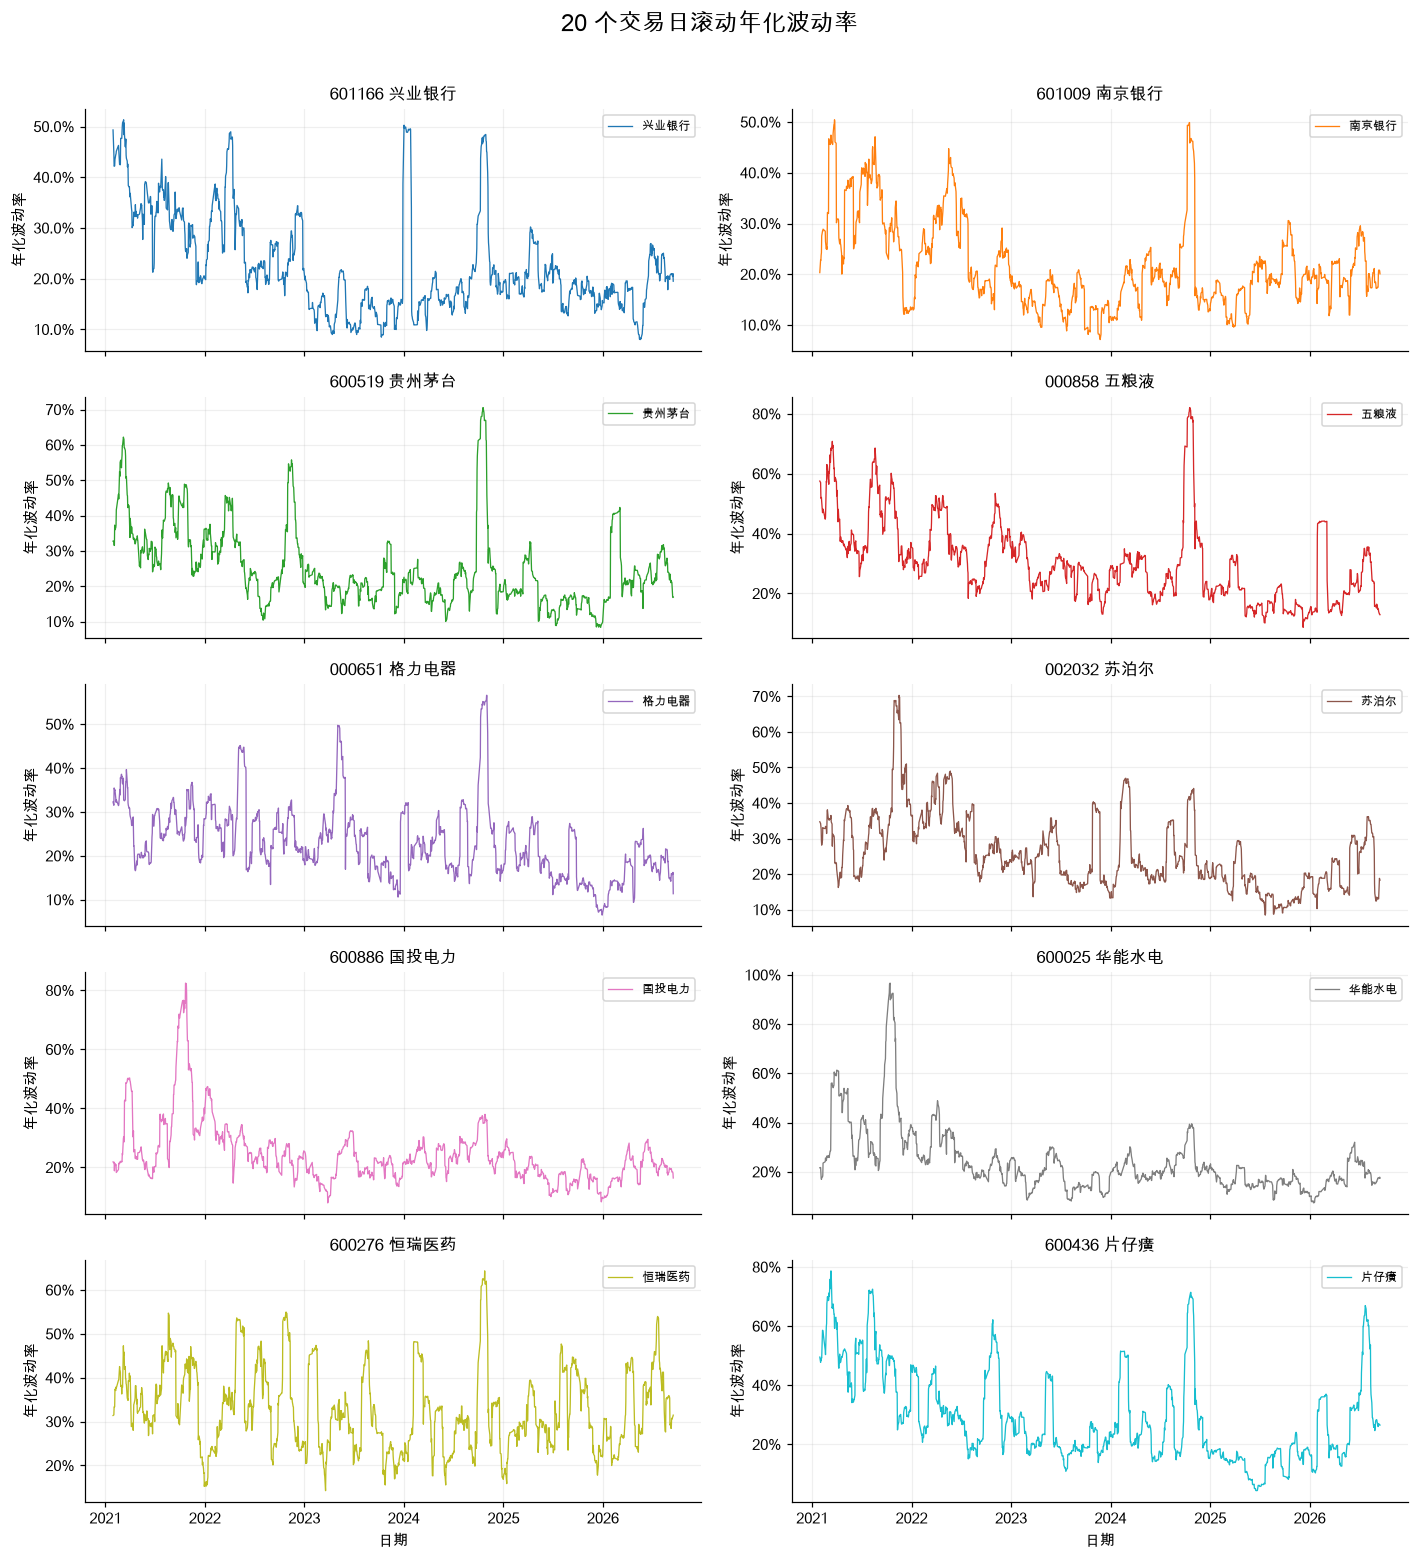

In [5]:
wealth=(1+returns).cumprod()
wealth=pd.concat([pd.DataFrame(1.0,index=[calendar[0]],columns=returns.columns),wealth])
rolling_vol=returns.rolling(20,min_periods=20).std(ddof=1)*np.sqrt(252)
assert rolling_vol.iloc[:19].isna().all().all()
fig,ax=plt.subplots(figsize=(12,5.5))
for c in STOCKS: ax.plot(wealth.index,wealth[c],label=names[c],color=colors[c],lw=1.3)
ax.set(title='累计收益净值（2020-12-31 = 1）',xlabel='日期',ylabel='净值 / 倍')
ax.legend(ncol=5,loc='upper center',bbox_to_anchor=(0.5,-0.15)); fig.tight_layout()
fig.savefig(RESULT/'03_stock_wealth.png',dpi=150); plt.show()
panel_lines(rolling_vol,'20 个交易日滚动年化波动率','年化波动率','04_rolling_vol.png',percent=True)

### 结果解读
同样以 1 为起点，华能水电期末净值为 2.526，累计收益 152.58%；五粮液期末净值为 0.286，累计收益 -71.39%。南京银行和国投电力累计收益分别为 98.80%、97.29%，而两只白酒和两只医药股票均为负，说明行业之间及行业内部的累计表现不同。

滚动波动率图的数值基于 20 个完整交易日，图中开头 19 个收益日留空。局部尖峰表示短期波动集中，并不意味着随后一定继续上涨或下跌。全样本风险的可比数值在下一节给出，不能仅从一段高波动图形判断长期回报。

- 累计收益使用连乘，保留日收益的路径效应。
- 本样本中较高的实现风险没有普遍对应较高的实现收益。
- 不将事后表现最好的股票反过来定义为事前最优选择。

## 6. 描述统计与相关性

### 分析说明
报告全部要求的分布指标：有效观测数、日均值、日标准差、最小值、中位数、最大值、偏度和超额峰度。pandas 的 `kurt` 为 Fisher 超额峰度，正态分布基准为 0。

所有股票均有完整的同一日历收益。相关性使用 2021-01-04—2026-09-16 的共同样本，无成对删失导致的样本量差异。计算 Pearson 相关系数，进一步将 45 对股票区分为同行业和跨行业比较。

,简称,有效观测数,日均值,日标准差,最小值,中位数,最大值,偏度,超额峰度,累计收益,几何年化收益,年化波动率
601166,兴业银行,1384,0.02%,1.56%,-8.51%,-0.05%,9.97%,0.220,3.911,18.45%,3.13%,24.80%
601009,南京银行,1384,0.06%,1.47%,-9.91%,0.00%,10.03%,0.007,4.743,98.80%,13.33%,23.28%
600519,贵州茅台,1384,-0.01%,1.72%,-7.56%,-0.10%,9.50%,0.584,4.332,-26.47%,-5.44%,27.25%
000858,五粮液,1384,-0.07%,2.09%,-9.98%,-0.21%,10.00%,0.447,3.730,-71.39%,-20.37%,33.12%
000651,格力电器,1384,0.01%,1.54%,-9.96%,-0.08%,9.64%,0.272,4.835,-7.82%,-1.47%,24.44%
002032,苏泊尔,1384,-0.01%,1.76%,-8.54%,-0.07%,10.01%,0.576,4.066,-32.14%,-6.82%,27.97%
600886,国投电力,1384,0.06%,1.64%,-8.66%,0.00%,9.98%,0.450,4.552,97.29%,13.17%,26.07%
600025,华能水电,1384,0.08%,1.69%,-9.95%,0.00%,10.10%,0.983,7.988,152.58%,18.38%,26.90%
600276,恒瑞医药,1384,-0.03%,2.14%,-10.00%,-0.16%,10.00%,0.372,2.900,-52.08%,-12.54%,33.98%
600436,片仔癀,1384,-0.03%,2.10%,-10.00%,-0.18%,10.00%,0.177,5.037,-54.06%,-13.21%,33.29%


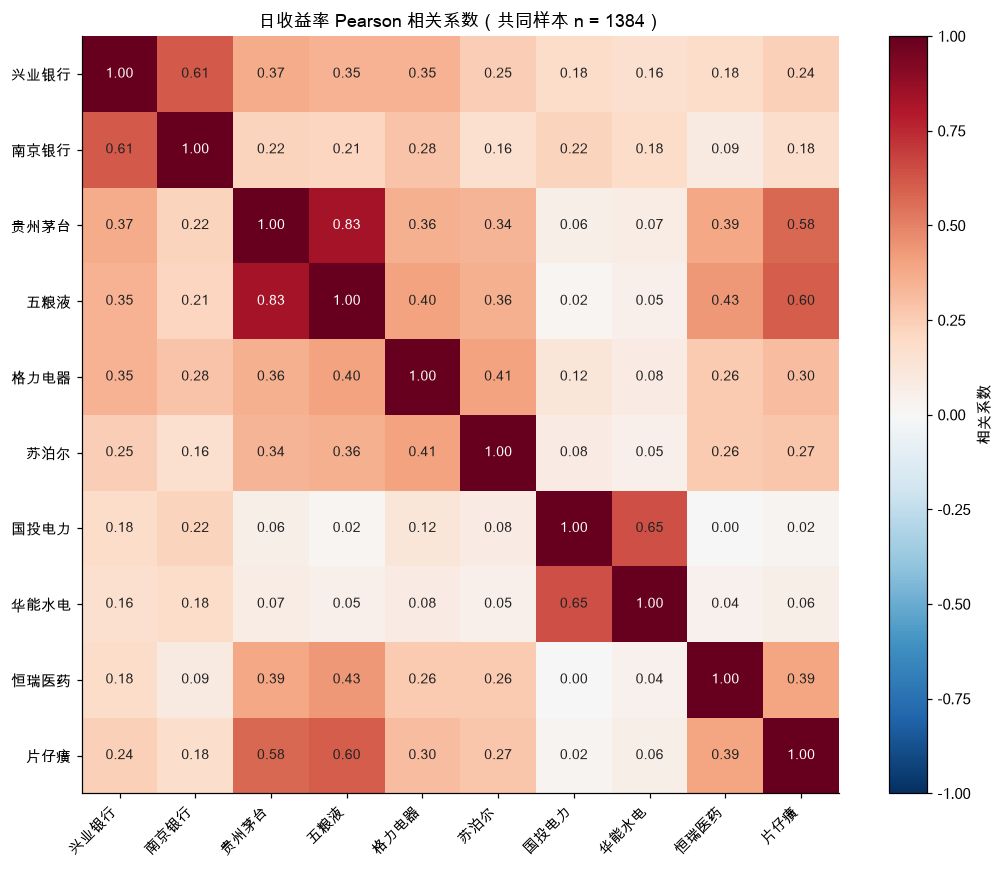

,count,mean,median,min,max
同行业,,,,,
False,40,0.221039,0.216926,0.004857,0.603323
True,5,0.578104,0.613036,0.394795,0.830335


In [6]:
stats=pd.DataFrame({'有效观测数':returns.count(),'日均值':returns.mean(),'日标准差':returns.std(ddof=1),
    '最小值':returns.min(),'中位数':returns.median(),'最大值':returns.max(),
    '偏度':returns.skew(),'超额峰度':returns.kurt(),
    '累计收益':wealth.iloc[-1]-1,'几何年化收益':wealth.iloc[-1]**(252/len(returns))-1,
    '年化波动率':returns.std(ddof=1)*np.sqrt(252)})
stats.insert(0,'简称',pd.Series(names))
display(stats.style.format({c:'{:.2%}' for c in ['日均值','日标准差','最小值','中位数','最大值','累计收益','几何年化收益','年化波动率']}|{'偏度':'{:.3f}','超额峰度':'{:.3f}'}))
stats.to_csv(RESULT/'stock_statistics.csv',encoding='utf-8-sig')
corr=returns.corr(method='pearson')
assert returns.count().nunique()==1
fig,ax=plt.subplots(figsize=(10,8))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu_r')
labels=[names[c] for c in corr.columns]
ax.set_xticks(range(10),labels,rotation=45,ha='right'); ax.set_yticks(range(10),labels)
ax.grid(False)
for i in range(10):
    for j in range(10):
        ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',color='white' if abs(corr.iloc[i,j])>0.65 else '#222',fontsize=9)
ax.set_title(f'日收益率 Pearson 相关系数（共同样本 n = {len(returns)}）')
fig.colorbar(im,ax=ax,label='相关系数'); fig.tight_layout()
fig.savefig(RESULT/'05_correlation.png',dpi=150); plt.show()
pairs=[]
for i,a in enumerate(corr.columns):
    for b in corr.columns[i+1:]:
        pairs.append({'股票1':names[a],'股票2':names[b],'同行业':selection.at[a,'行业']==selection.at[b,'行业'],'相关系数':corr.at[a,b]})
pairs=pd.DataFrame(pairs)
display(pairs.groupby('同行业')['相关系数'].agg(['count','mean','median','min','max']))
corr.to_csv(RESULT/'correlation.csv',encoding='utf-8-sig')
summary['stock_stats']=stats.reset_index(names='代码').to_dict('records')
summary['pairs']=pairs.to_dict('records')

### 描述统计解读
恒瑞医药年化波动率最高，为 33.98%，但几何年化收益为 -12.54%；南京银行波动率最低，为 23.28%，几何年化收益为 13.33%。华能水电的几何年化收益为 18.38%、年化波动率为 26.90%。这些实现结果不支持“承担更高波动就一定获得更高回报”的简单判断。

十只股票的超额峰度均为正，华能水电达到 7.99，高于正态分布基准 0，说明样本包含相对突出的尾部和集中波动。均值、中位数和偏度提供不同信息；如兴业银行日均收益为 0.02%，但中位数为 -0.05%，正均值并不等于多数交易日上涨。

- 每只股票有效收益数均为 1384，统计量可在同一时期比较。
- 超额峰度不是普通峰度，不能再减一次 3。
- 几何年化收益考虑复利，与日均收益乘 252 的算术年化不同。

### 相关性解读
5 对同行业股票的平均相关系数为 0.578，40 对跨行业股票为 0.221，同行业整体更相关。最高的一对是贵州茅台与五粮液（0.830），最低的一对是国投电力与恒瑞医药（0.005）。共同需求、成本或估值因素是可能解释，相关矩阵本身没有识别这些机制。

- 行业内相关性也有差别，医药和家电企业并非相同业务。
- 跨行业相关性较低，为分散投资提供样本内依据；危机期相关性可能变化。
- 全部相关系数基于相同的 1384 个日期，无成对删失样本量差异。

## 7. 等权与滞后总市值加权组合

### 分析说明
设每日等权目标为 10%，市值权重为上一交易日各股总市值占本篮子总市值的比例：

$$r^{EW}_{p,t}=\sum_i 0.1r_{i,t},\qquad
w_{i,t-1}=\frac{MV_{i,t-1}}{\sum_j MV_{j,t-1}},\qquad
r^{VW}_{p,t}=\sum_iw_{i,t-1}r_{i,t}.$$

两者每日按目标权重计算，忽略交易成本。等权不是初始买入后任其权重漂移；市值权重也不是使用期末或当前市值固定分配。下面展示期初权重、权重均值与范围、以及 Herfindahl 指数（HHI）衡量集中程度；$1/HHI$ 可理解为等效持股数量。

,简称,首日权重,平均权重,最小权重,最大权重,末日权重
601166,兴业银行,7.90%,9.41%,6.90%,13.35%,11.52%
601009,南京银行,1.47%,2.64%,1.33%,4.61%,4.57%
600519,贵州茅台,45.72%,49.62%,44.17%,55.65%,48.31%
000858,五粮液,20.64%,14.61%,8.13%,22.06%,8.22%
000651,格力电器,6.79%,5.48%,3.91%,7.03%,6.51%
002032,苏泊尔,1.17%,1.01%,0.77%,1.24%,0.97%
600886,国投电力,1.10%,2.34%,0.87%,3.81%,3.53%
600025,华能水电,1.46%,3.58%,1.24%,5.93%,5.53%
600276,恒瑞医药,10.82%,7.67%,4.25%,12.09%,8.69%
600436,片仔癀,2.94%,3.64%,2.06%,5.97%,2.15%


,平均HHI,平均等效持股数量,平均最大单股权重
等权组合,0.100000,10.000000,0.100000
市值加权组合,0.291885,3.452041,0.496215


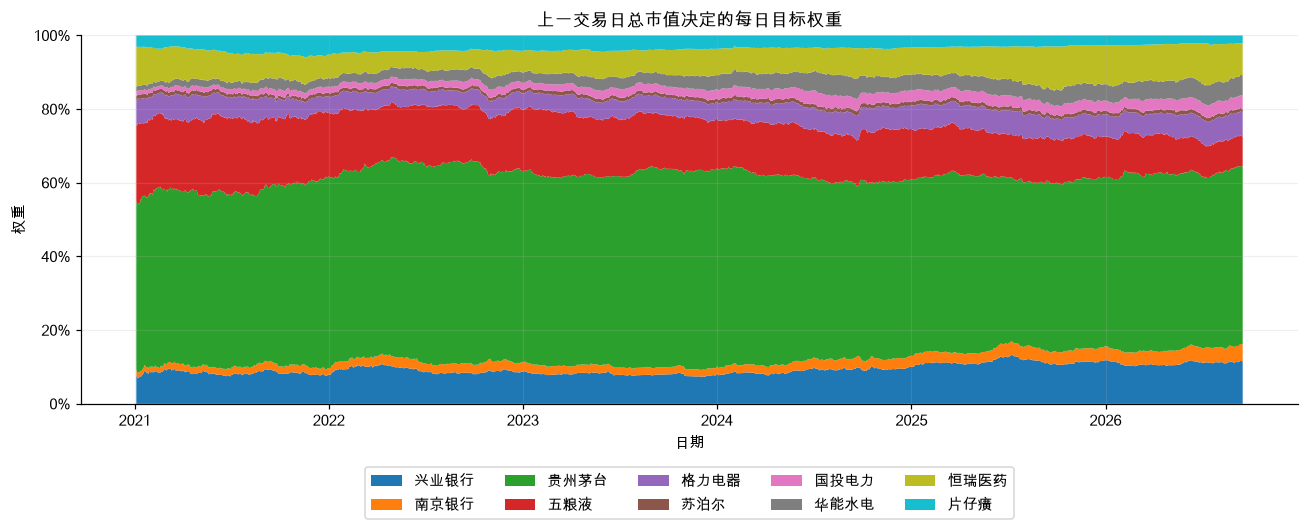

In [7]:
# 先在完整交易日历上移位，再截取收益样本。
lag_mv=mv.shift(1).reindex(returns.index)
w_vw=lag_mv.div(lag_mv.sum(axis=1,min_count=10),axis=0)
w_ew=pd.DataFrame(0.1,index=returns.index,columns=returns.columns)
assert w_vw.notna().all().all() and (w_vw>=0).all().all()
assert np.allclose(w_vw.sum(axis=1),1) and np.allclose(w_ew.sum(axis=1),1)
assert np.allclose(w_vw.iloc[0],mv.iloc[0]/mv.iloc[0].sum())
port=pd.DataFrame({'等权组合':(returns*w_ew).sum(axis=1,min_count=10),
                   '市值加权组合':(returns*w_vw).sum(axis=1,min_count=10)})
weight_table=pd.DataFrame({'简称':pd.Series(names),'首日权重':w_vw.iloc[0],
    '平均权重':w_vw.mean(),'最小权重':w_vw.min(),'最大权重':w_vw.max(),'末日权重':w_vw.iloc[-1]})
display(weight_table.style.format({c:'{:.2%}' for c in weight_table.columns if c!='简称'}))
hhi=(w_vw**2).sum(axis=1)
concentration=pd.DataFrame({'平均HHI':[0.1,hhi.mean()],
    '平均等效持股数量':[10,(1/hhi).mean()],
    '平均最大单股权重':[0.1,w_vw.max(axis=1).mean()]},index=['等权组合','市值加权组合'])
display(concentration)
fig,ax=plt.subplots(figsize=(12,5))
ax.stackplot(w_vw.index,w_vw.T,labels=[names[c] for c in w_vw.columns],colors=[colors[c] for c in w_vw.columns])
ax.set(title='上一交易日总市值决定的每日目标权重',xlabel='日期',ylabel='权重')
ax.set_ylim(0,1); ax.yaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.legend(ncol=5,loc='upper center',bbox_to_anchor=(0.5,-0.15)); fig.tight_layout()
fig.savefig(RESULT/'06_market_weights.png',dpi=150); plt.show()
weight_table.to_csv(RESULT/'weights_summary.csv',encoding='utf-8-sig')
w_vw.to_csv(RESULT/'daily_market_weights.csv',encoding='utf-8-sig')
summary['weights']=weight_table.reset_index(names='代码').to_dict('records')
summary['concentration']=concentration.reset_index(names='组合').to_dict('records')

### 权重解读
市值加权组合中，贵州茅台平均权重为 49.62%，最高达到 55.65%；五粮液平均为 14.61%。两只白酒合计平均占 64.23%，远高于等权组合的 20%。相比之下，国投电力和华能水电合计平均权重仅为 5.92%。

市值组合平均 HHI 为 0.292、平均等效持股数量为 3.45，等权分别为 0.100 和 10。因此“持有 10 只股票”不代表两种方案有相同的集中程度。主导权重的白酒股在此期间表现较弱，是后面组合表现差异的重要描述性线索；这里没有将单股累计收益简单加权冒充正式归因。

- 权重由 $t-1$ 日总市值决定，每日和为 1，未使用当日收盘后信息。
- 本题比较的是固定篮子中的规则，市值加权结果不代表整个市场指数。
- 每日恢复目标权重且无成本的设定与实际可交易组合存在差距。

## 8. 组合绩效与风险比较

### 分析说明
用同一段连续交易日收益计算两类组合的累计收益、几何年化收益、年化波动率与非负最大回撤：

$$R_{ann}=\left[\prod_{t=1}^{T}(1+r_{p,t})\right]^{252/T}-1,\quad
\sigma_{ann}=s(r_{p,t})\sqrt{252},\quad
MDD=\max_t\left(1-\frac{V_t}{\max_{s\le t}V_s}\right).$$

净值中显式加入初始值 1，保证首次下跌也计入回撤。波动率从组合日收益率计算。比较组合波动与个股波动平均值仅用于展示分散作用，后者不作为组合风险估计。

,累计收益率,几何年化收益率,年化波动率,最大回撤,有效收益日数
等权组合,3.88%,0.70%,16.42%,26.45%,1384
市值加权组合,-29.65%,-6.20%,22.11%,46.65%,1384


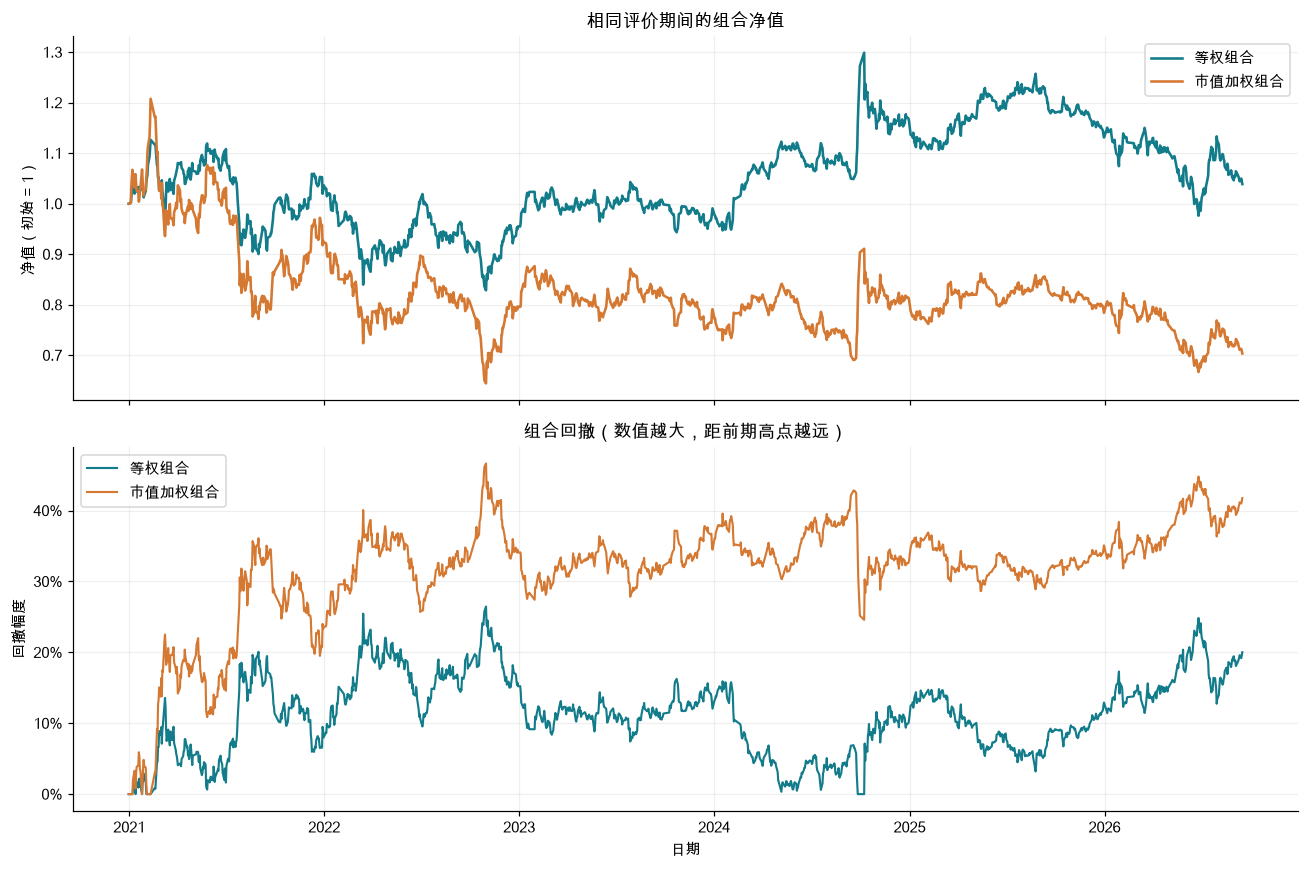

权重日期、权重和、复利年化、初始净值回撤、等权协方差及逐日加权核验均通过。


,复权口径,组合,累计收益率,几何年化收益率,年化波动率,最大回撤
0,新浪因子（主分析）,等权组合,3.88%,0.70%,16.42%,26.45%
1,新浪因子（主分析）,市值加权组合,-29.65%,-6.20%,22.11%,46.65%
2,腾讯前复权（比较）,等权组合,10.74%,1.87%,18.91%,29.21%
3,腾讯前复权（比较）,市值加权组合,-30.47%,-6.40%,24.63%,50.83%


18551

In [8]:
port_wealth=pd.concat([pd.DataFrame(1.0,index=[calendar[0]],columns=port.columns),(1+port).cumprod()])
drawdown=1-port_wealth/port_wealth.cummax()
metrics=pd.DataFrame({'累计收益率':port_wealth.iloc[-1]-1,
    '几何年化收益率':port_wealth.iloc[-1]**(252/len(port))-1,
    '年化波动率':port.std(ddof=1)*np.sqrt(252),
    '最大回撤':drawdown.max(),'有效收益日数':len(port)})
display(metrics.style.format({c:'{:.2%}' for c in metrics.columns if c!='有效收益日数'}|{'有效收益日数':'{:.0f}'}))
fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True)
for label,color in zip(port.columns,['#137C8B','#D57832']):
    axes[0].plot(port_wealth.index,port_wealth[label],label=label,color=color,lw=1.7)
    axes[1].plot(drawdown.index,drawdown[label],label=label,color=color,lw=1.4)
axes[0].set(title='相同评价期间的组合净值',ylabel='净值（初始 = 1）'); axes[0].legend()
axes[1].set(title='组合回撤（数值越大，距前期高点越远）',ylabel='回撤幅度',xlabel='日期')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1)); axes[1].legend()
fig.tight_layout(); fig.savefig(RESULT/'07_portfolio_performance.png',dpi=150); plt.show()

# 独立计算核验，避免仅检查“运行没有报错”。
for label in port:
    assert np.isclose(metrics.at[label,'几何年化收益率'],np.expm1(np.log1p(port[label]).sum()*252/len(port)))
    values=port_wealth[label].to_numpy(); peak=1.0; worst=0.0
    for v in values: peak=max(peak,v); worst=max(worst,1-v/peak)
    assert np.isclose(worst,metrics.at[label,'最大回撤'])
ew=np.repeat(0.1,10)
assert np.isclose(metrics.at['等权组合','年化波动率'],np.sqrt(ew@returns.cov().to_numpy()@ew*252))
assert np.allclose(port['市值加权组合'].to_numpy(),np.einsum('ij,ij->i',returns.to_numpy(),w_vw.to_numpy()))
print('权重日期、权重和、复利年化、初始净值回撤、等权协方差及逐日加权核验均通过。')
port.to_csv(RESULT/'daily_portfolio_returns.csv',encoding='utf-8-sig')
metrics.to_csv(RESULT/'portfolio_metrics.csv',encoding='utf-8-sig')
summary['metrics']=metrics.reset_index(names='组合').to_dict('records')
summary['diversification']={'mean_individual_vol':float(stats['年化波动率'].mean()),
                          'ew_vol':float(metrics.at['等权组合','年化波动率'])}
summary['drawdown_dates']={label:drawdown[label].idxmax().strftime('%Y-%m-%d') for label in port}
# 对会影响结论的复权口径作同样本、同权重比较，不用删尾值掩盖差异。
tx_ret=tx_adj.pct_change(fill_method=None).reindex(returns.index)
sensitivity=[]
for method,retdf in [('新浪因子（主分析）',returns),('腾讯前复权（比较）',tx_ret)]:
    for label,w in [('等权组合',w_ew),('市值加权组合',w_vw)]:
        r=(retdf*w).sum(axis=1,min_count=10)
        v=np.r_[1.0,(1+r).cumprod().to_numpy()]
        sensitivity.append({'复权口径':method,'组合':label,'累计收益率':v[-1]-1,
            '几何年化收益率':v[-1]**(252/len(r))-1,'年化波动率':r.std(ddof=1)*np.sqrt(252),
            '最大回撤':(1-v/np.maximum.accumulate(v)).max()})
sensitivity=pd.DataFrame(sensitivity)
display(sensitivity.style.format({c:'{:.2%}' for c in sensitivity.columns[2:]}))
sensitivity.to_csv(RESULT/'adjustment_sensitivity.csv',index=False,encoding='utf-8-sig')
summary['sensitivity']=sensitivity.to_dict('records')
summary['tx_extreme_count']=int((tx_ret.abs()>0.105).sum().sum())
summary['gree_example']={'tx':float(tx_ret.loc['2022-05-05','000651']),
    'main':float(returns.loc['2022-05-05','000651']), 'raw':float(raw_returns.loc['2022-05-05','000651'])}
no_action=factor.pct_change(fill_method=None).reindex(returns.index).abs()<1e-10
assert (returns.sub(raw_returns).where(no_action).abs().max().max())<1e-9
summary['non_action_consistency']=float(returns.sub(raw_returns).where(no_action).abs().max().max())
(RESULT/'report_numbers.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')

### 组合结果解读
等权组合累计收益 3.88%、几何年化收益 0.70%，市值加权分别为 -29.65%、-6.20%。等权年化波动率 16.42%，低于市值加权的 22.11%；最大回撤分别为 26.45% 与 46.65%，均发生在 2022-10-31。本样本内等权在上述指标上表现更好。

个股年化波动率的算术平均为 28.11%，等权组合为 16.42%。这一下降来自收益协方差结构，不能通过直接平均个股标准差得到。即使期末累计收益为正，等权期间仍曾回撤超过四分之一，说明累计回报与持有过程中的损失风险是不同概念。

- 同一连续评价期、同样 1,384 个收益日，未通过删失日期改变年化分母。
- 市值集中在白酒，等权给银行、电力更多相对权重，有助于解释差异。
- 结论只对选定股票和这段历史成立，不构成未来收益预测。

## 9. 复权口径敏感性：处理决定是否影响结论

第 8 节最后一表固定股票、日期、原始市值权重和所有绩效公式，仅替换用于收益率的复权口径。腾讯前复权口径下，等权组合年化收益为 1.87%、波动率 18.91%；新浪因子主口径分别为 0.70%、16.42%。市值加权组合年化收益从腾讯口径的 -6.40% 变为 -6.20%，最大回撤从 50.83% 变为 46.65%。

因此口径对数值影响明显，“等权在这段样本内收益较高、波动和最大回撤较低”的排序在两种口径下保持一致。选择新浪因子的依据是非公司行为日收益与原始价格变化一致，以及同源前后复权因子互相验证，不是为了得到更好的组合收益。

- 主分析未缩尾，保留全部有效观测。
- 这一比较覆盖复权口径，未覆盖交易成本、税费、不同股票篮子或不同研究区间。
- 不把数据商前复权价的历史涨幅直接等同于当日实际成交价格涨幅。

## 总体结论

在 2021-01-04 至 2026-09-16 的 1,384 个共同交易日中，银行和电力样本整体累计表现好于所选白酒、家电和医药样本。华能水电累计收益最高（152.58%），五粮液最低（-71.39%），个股实现风险与实现收益没有呈现简单的一一对应关系。同行业平均相关系数 0.578 高于跨行业的 0.221，不同业务的组合能降低一部分样本内共同波动。

等权组合年化收益 0.70%、年化波动 16.42%、最大回撤 26.45%；市值加权分别为 -6.20%、22.11%、46.65%。市值方案的贵州茅台平均权重约 49.62%，篮子集中程度明显更高，是比较权重规则时必须考虑的事实。分散投资降低了波动，但没有消除明显回撤。

关键处理是使用完整共同交易日历、以 2020-12-31 初始化价格和滞后市值、以新浪生效因子统一调整公司行为、保持原始股价和复权价用途分离，并对复权口径作敏感性比较。没有填补收益、缩尾或把不连续观测当成连续日收益。局限包括事后挑选且偏向持续交易股票、行业分类使用下载日快照、依赖数据商公司行为因子、每日再平衡忽略交易费用，以及缺少滚动样本外检验。结果可以支持本篮子的历史描述，不能推广为普遍策略优劣或产权、行业等因素的因果效应。

## 10. 可复现性、AI 使用与本人核验

### 可复现性
从完整仓库进入 `hw02-1/`，安装本题 `requirements.txt`，重启内核并从头运行。分析只读 `data/raw/` 快照。辅助下载脚本、数据来源清单及全部主要结果随仓库提供；不能只下载本 Notebook 后声称能复现。个人信息仅在坚果云提交版保留完整学号，公开版另作脱敏。

### AI 使用声明
- 工具：OpenAI Codex。
- 参与环节：接口检索、公开数据获取、数据审计、Python 代码、图表及分析文字草稿、从头运行和独立公式核验。
- 关键提示词：“按 HW02-1 的指定期间获取十只 A 股的原始价、复权价和历史总市值，先检查主键、日历、单位与异常，再用上一交易日总市值构造权重，保存快照并说明所有处理。”
- 发现并修正的问题：东方财富行情接口无法连接，改用腾讯行情并用东方财富历史收盘价交叉核验；最初候选有停牌缺口，更换为同行业完整覆盖股票并保留原始审计资料；识别腾讯接口部分证券成交量单位分支差异，采用定义明确的成交额字段；异常收益核验发现腾讯前复权口径可放大部分历史涨跌，改用新浪乘法复权因子并作同权重口径比较；显式加入初始净值以避免漏算起始回撤。
- 自动核验：输入校验值、股票与日期主键、样本覆盖、跨源价格、历史市值口径、权重移位、年化与回撤的独立计算、重启运行、图表中文显示。
- 本人核验状态：待毛博平阅读并核对至少一只股票的一天收益、首日市值权重与总体结论，再如实补充本人检查记录。此处不预填“本人已核验”。

### 来源
1. [教师作业页面](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)。
2. [AKShare 股票接口文档](https://akshare.akfamily.xyz/data/stock/stock.html)：`stock_zh_a_hist_tx`、`stock_zh_a_daily`（复权因子）、`stock_value_em`。
3. [腾讯证券](https://gu.qq.com/sh600519)：冻结历史行情。
4. [东方财富估值分析](https://data.eastmoney.com/gzfx/detail/600519.html)：历史总市值与跨源价格。
5. [东方财富公司概况](https://emweb.securities.eastmoney.com/PC_HSF10/CompanySurvey/Index?type=web&code=SH600519)：`RPT_F10_ORG_BASICINFO`，使用 `EM2016`、`LISTING_DATE`。
6. [新浪财经](https://finance.sina.com.cn/realstock/company/sz000651/nc.shtml)：冻结前后复权因子，日期为因子生效日期。
7. [宁波银行配股说明书](https://static.cninfo.com.cn/finalpage/2021-11-19/1211627066.PDF)：初始候选的停牌背景。未依据此文件计算本报告的最终组合。